In [69]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [70]:
import warnings
warnings.filterwarnings('ignore')

In [71]:
sns.set_style('darkgrid')
sns.set_palette('magma')

In [72]:
df = pd.read_csv('../datas/heart.csv')

In [73]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [74]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [75]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(723)

In [77]:
df = df.drop_duplicates()

In [78]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [79]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [80]:
# Check data balance
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

# PLOT DISTRUBUTIONS OF SOME DATAS

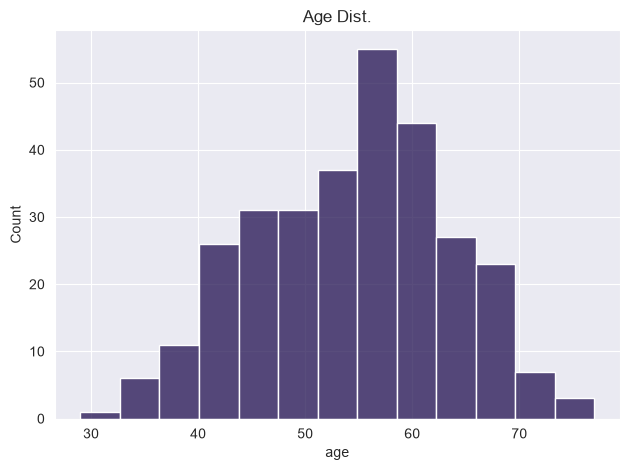

In [81]:
sns.histplot(df['age'])
plt.title('Age Dist.')
plt.tight_layout()

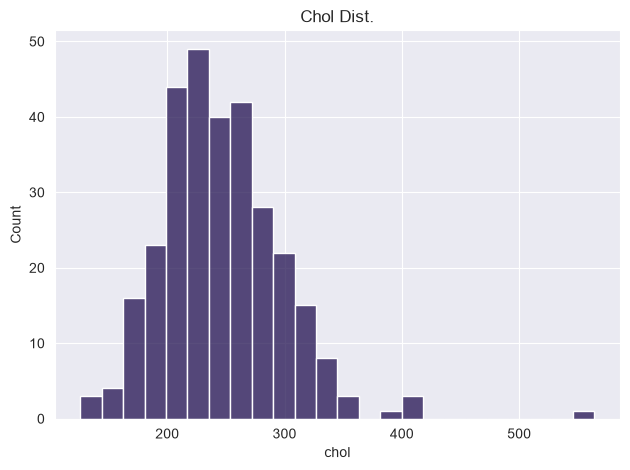

In [82]:
sns.histplot(df['chol'])
plt.title('Chol Dist.')
plt.tight_layout()

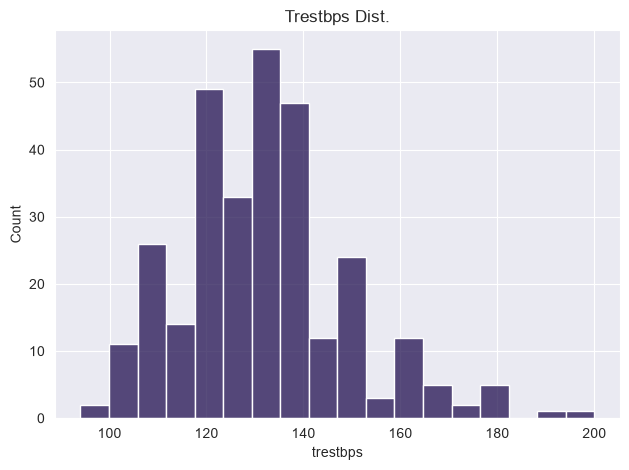

In [83]:
sns.histplot(df['trestbps'])
plt.title('Trestbps Dist.')
plt.tight_layout()

# OTHER PLOTS

<Axes: >

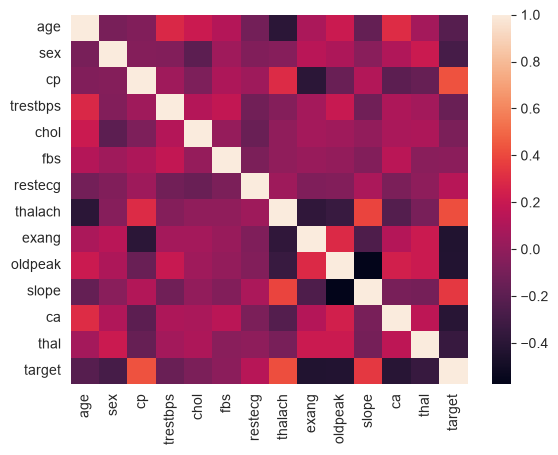

In [84]:
sns.heatmap(df.corr())

<Axes: xlabel='age', ylabel='Count'>

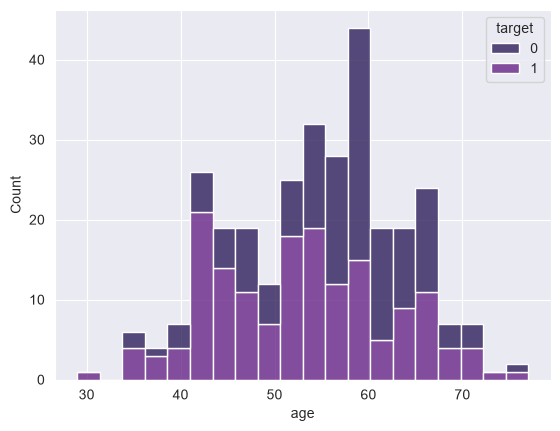

In [85]:
sns.histplot(data=df, x='age', hue='target', multiple='stack' ,bins=20)

<Axes: xlabel='age', ylabel='chol'>

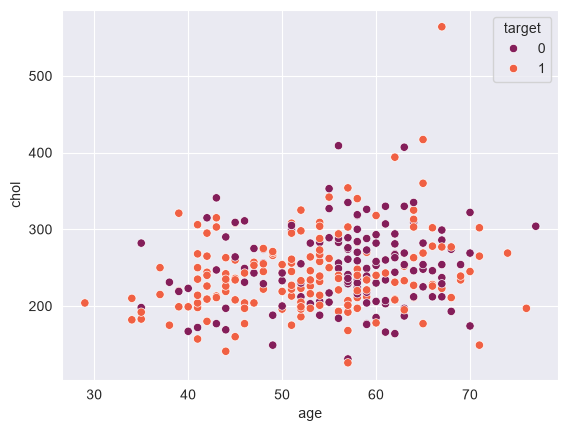

In [86]:
sns.scatterplot(data=df, x='age', y='chol', hue='target', palette='rocket')

<Axes: xlabel='target', ylabel='count'>

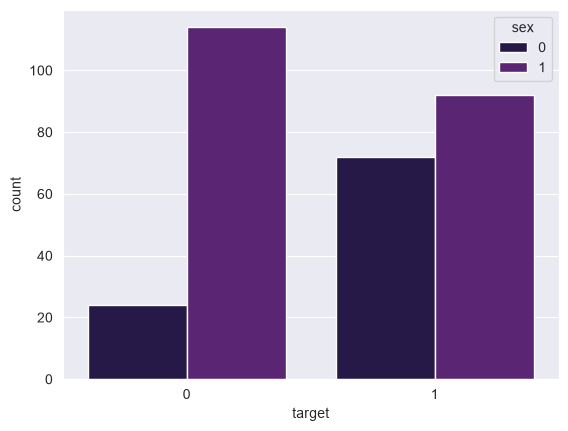

In [87]:
sns.countplot(data=df, x='target', hue='sex')

<Axes: xlabel='target', ylabel='chol'>

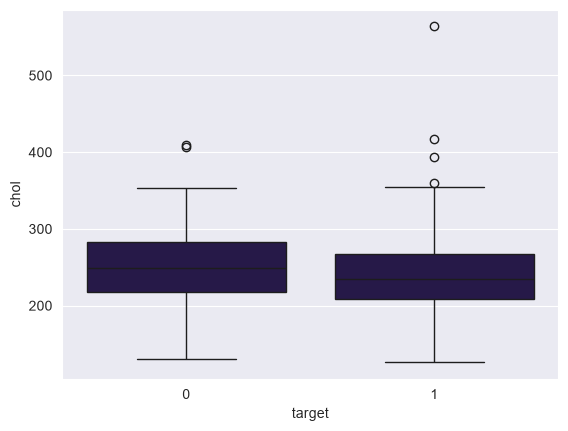

In [88]:
sns.boxplot(data=df, x='target', y='chol')

# BUILD PREPROCESSOR AND EVALUATE BASELINE MODELS

In [89]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.svm import SVR
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

In [90]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X train shape:', X_train.shape,
      '\nX test shape:', X_test.shape,
      '\ny train shape:', y_train.shape,
      '\ny test shape:', y_test.shape,
      )

X train shape: (241, 13) 
X test shape: (61, 13) 
y train shape: (241,) 
y test shape: (61,)


In [91]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
], remainder='passthrough')

In [92]:
models = {
    'XGBClassifier':XGBClassifier(n_estimators=100),
    'LogisticRegression' : LogisticRegression(random_state=42),
    'RandomForestClassifier' : RandomForestClassifier(random_state=42),
    'LightGBM' : LGBMClassifier(random_state=42)
}

In [93]:
scores = {}
for model_name, model in models.items():
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    model_pipeline.fit(X_train, y_train)
    y_pred_test = model_pipeline.predict(X_test)
    y_pred_train = model_pipeline.predict(X_train)

    score_f1_test = f1_score(y_test, y_pred_test)
    score_f1_train = f1_score(y_train, y_pred_train)
    score_recall_test = recall_score(y_test, y_pred_test)
    score_recall_train = recall_score(y_train, y_pred_train)
    score_accuracy_test = accuracy_score(y_test, y_pred_test)
    score_accuracy_train = accuracy_score(y_train, y_pred_train)
    score_precision_test = precision_score(y_test, y_pred_test)
    score_precision_train = precision_score(y_train, y_pred_train)

    scores[model_name] = {
        'accuracy_test': score_accuracy_test,
        'accuracy_train': score_accuracy_train,
        'precision_test': score_precision_test,
        'precision_train': score_precision_train,
        'recall_test': score_recall_test,
        'recall_train': score_recall_train,
        'f1_test': score_f1_test,
        'f1_train': score_f1_train
    }

basemodel_df = pd.DataFrame(scores)     

[LightGBM] [Info] Number of positive: 135, number of negative: 106
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 243
[LightGBM] [Info] Number of data points in the train set: 241, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.560166 -> initscore=0.241836
[LightGBM] [Info] Start training from score 0.241836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [94]:
basemodel_df

,XGBClassifier,LogisticRegression,RandomForestClassifier,LightGBM
accuracy_test,0.803279,0.786885,0.836066,0.803279
accuracy_train,1.000000,0.871369,1.000000,1.000000
precision_test,0.757576,0.722222,0.787879,0.757576
precision_train,1.000000,0.856164,1.000000,1.000000
recall_test,0.862069,0.896552,0.896552,0.862069
recall_train,1.000000,0.925926,1.000000,1.000000
f1_test,0.806452,0.800000,0.838710,0.806452
f1_train,1.000000,0.889680,1.000000,1.000000


# CHOOSE AND TUNE BEST BASELINE MODEL

In [95]:
lgbm_param_grid = {
    'model__num_leaves': [15, 31, 63],    
    'model__max_depth': [-1, 3, 5, 7],           
    'model__min_child_samples': [10, 20, 30],     
    'model__n_estimators': [50, 100, 200],       
    'model__learning_rate': [0.01, 0.05, 0.1],    
    'model__reg_alpha': [0.0, 0.1, 1.0],         
    'model__reg_lambda': [0.0, 1.0, 5.0],       
    'model__subsample': [0.8, 1.0],              
    'model__colsample_bytree': [0.8, 1.0]        
}

In [96]:
lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42))
])

In [97]:
rsv = RandomizedSearchCV(estimator=lgbm_model, param_distributions=lgbm_param_grid,scoring='recall', n_jobs=-1, random_state=42)
rsv.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 135, number of negative: 106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 243
[LightGBM] [Info] Number of data points in the train set: 241, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.560166 -> initscore=0.241836
[LightGBM] [Info] Start training from score 0.241836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 3, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)K

In [98]:
print('Best parameters: ', rsv.best_params_)
print('Best recall score: ', rsv.best_score_)

Best parameters:  {'model__subsample': 0.8, 'model__reg_lambda': 1.0, 'model__reg_alpha': 1.0, 'model__num_leaves': 63, 'model__n_estimators': 50, 'model__min_child_samples': 30, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best recall score:  0.9185185185185185


In [99]:
best_model = rsv.best_estimator_
y_pred = best_model.predict(X_test)

print('Test Accuracy :', accuracy_score(y_test, y_pred))
print('Test Precision:', precision_score(y_test, y_pred))
print('Test Recall   :', recall_score(y_test, y_pred))
print('Test F1       :', f1_score(y_test, y_pred))

Test Accuracy : 0.7540983606557377
Test Precision: 0.675
Test Recall   : 0.9310344827586207
Test F1       : 0.782608695652174


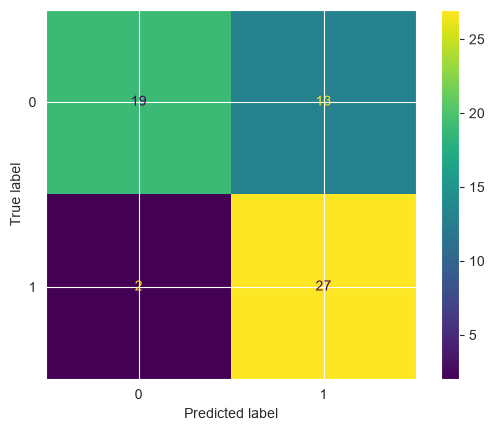

In [100]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred )

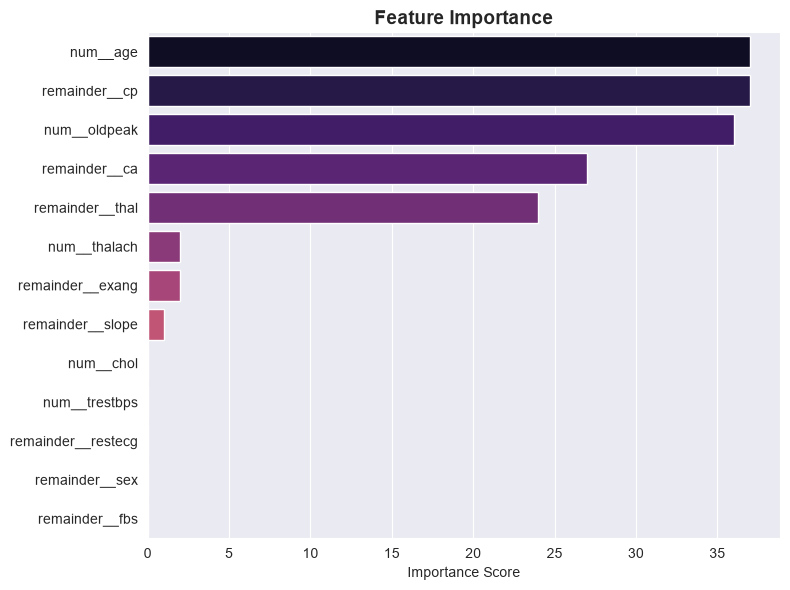

In [101]:
importances = best_model.named_steps['model'].feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=importance_df,
    x='importance', y='feature',
    palette='magma'
)
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()